# Parameters

In [32]:
from common.utils import (
    omega_c,
    delta0_from_N_Gamma,
    Omega0_from_N_Gamma,
    default_three_phase_protocol,
)

from pathlib import Path

%reload_ext autoreload
%autoreload 2

output_dir = Path("output")

### Parameters

In [55]:
# common fixed
Gamma = 1; dt = 1e-2; num_snapshots=100
# param
N = 20 
dN = 0
N1 = 10
omega1 = 1.0
ntraj = 100
# Model and parameters
Omega_ratio = 0.4
Omega0 = Omega_ratio * omega_c(N//2, Gamma)
delta0 = 1
# protocol phases
phases = default_three_phase_protocol(
    T1=10.0,
    T2=10.0,
    T3=10.0,
    delta0=delta0,
    Omega0=Omega0,
)

### MomentSeries Initialization

In [56]:
from common.utils import omega2_from_weighted_average
from parser.moments import MomentParameters, MomentSeries

N2 = N - N1
omega2 = omega2_from_weighted_average(omega1, N1, N2)

parameters = MomentParameters(
    Gamma=Gamma,
    phases=phases,
    omega_groups=(omega1, omega2),
    N_groups=(N1, N2),
)

# Initialize moments
mcwf_moments = MomentSeries(
    phases=phases,
    num_snapshots=num_snapshots,
    parameters=parameters,
    )

mfe_moments = MomentSeries(
    phases=phases,
    num_snapshots=num_snapshots,
    parameters=parameters,
    )

mc_qutip_moments = MomentSeries(
    phases=phases,
    num_snapshots=num_snapshots,
    parameters=parameters,
    )


### Mean-field Equations

In [57]:
from mfe.sim import compute_mfe_j_moments, solve_mfe
from parser.mfe import MFEInitialState, MFESolverParameters


inh_mfe_parameters = MFESolverParameters(
    Gamma=Gamma,
    phases=phases,
    omega_groups=(omega1, omega2),
    N_j_groups=(N1 // 2, N2 // 2),
)
initial_state_inh = MFEInitialState(
    theta_groups=(0.0, 0.0),
    phi_groups=(0.0, 0.0),
)
mfe_result = solve_mfe(
    inh_mfe_parameters,
    initial_state_inh,
    t_eval=mfe_moments.t,
)

mfe_moments.J = compute_mfe_j_moments(mfe_result)


### Monte-Carlo Wave Function

In [58]:
from quantum_trajectories.run_sim import (
    run_h_sim,
    run_inh_sim,
)
from quantum_trajectories.j_moments import compute_mcwf_j_moments

mcwf_ensemble = run_inh_sim(
    N=N,
    dN=dN,
    N1=N1,
    omega_1=omega1,
    dt=dt,
    Gamma=Gamma,
    phases=phases,
    shifted_jump_operator=True,
    ntraj=ntraj,
    num_snapshots=num_snapshots,
    seed=1234,
    n_processes=-1,
    )

mcwf_moments.J = compute_mcwf_j_moments(
    mcwf_ensemble,
    n_processes=-1,
)

Precompute: 0.02 seconds.
Pool startup: 10 processes in 0.32 seconds.


simulate trajectories: 100%|██████████| 100/100 [00:01<00:00, 52.79it/s]

Simulation step summary (avg per trajectory): total steps=3086.89, steps without precompute=116.87
inhomogeneous simulation runtime: 2.269360542006325



compute_mcwf_j_moments: 100%|██████████| 100/100 [00:01<00:00, 75.65it/s]


In [59]:
from quantum_trajectories_qutip.sim import (
    simulate_fixed_nj_mc_trajectory,
    simulate_fixed_nj_me_trajectory
)
from quantum_trajectories_qutip.j_moments import compute_qutip_j_moments

mc_qutip_ensamble = simulate_fixed_nj_me_trajectory(
        N=N,
        Gamma=Gamma,
        phases=phases,
        num_points=600,
        shifted_jump_operator=True,
    )
mc_qutip_moments.J = compute_qutip_j_moments(
    mc_qutip_ensamble,
)

ValueError: plot_bloch_angles requires full theta/phi fields or group-resolved theta_groups/phi_groups.

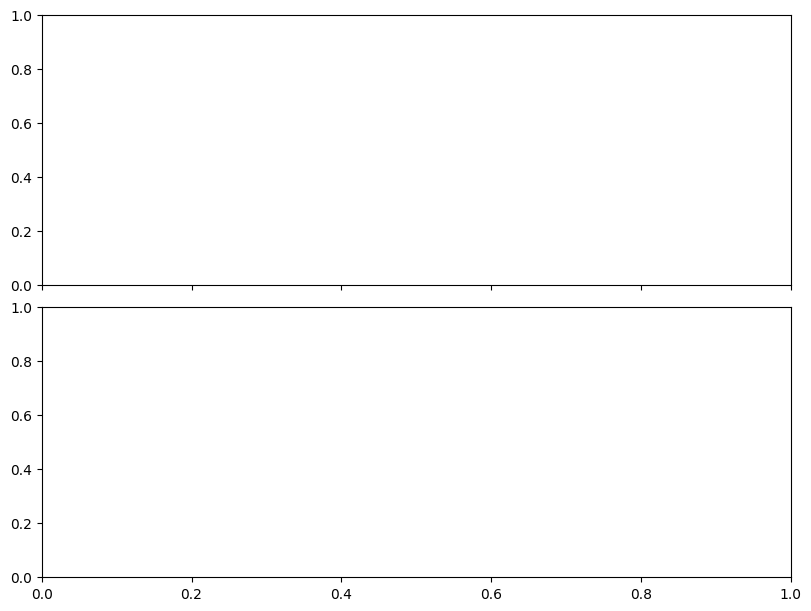

In [ ]:
from common.plotting import (
    plot_bloch_angles,
    plot_spin_components,
)

# fig, axes = plot_bloch_angles(
#     mcwf_moments.J,
#     phases=phases,
#     label="MCWF",
#     colour_index=0,
#     linestyle="--",
# )
fig, axes = plot_bloch_angles(
    mc_qutip_moments.J,
    phases=phases,
    label="MCQutip",
    colour_index=0,
    linestyle=":",
)
fig, axes = plot_bloch_angles(
    mfe_moments.J,
    phases=phases,
    label="MFE",
    axes=axes,
    colour_index=0,
    output_path=output_dir / "angles_equal.png",
)

fig, axes = plot_spin_components(
    mcwf_moments.J,
    normalized=True,
    phases=phases,
    label="MCWF",
    colour_index=0,
    linestyle="--",
)

fig, axes = plot_spin_components(
    mfe_moments.J,
    normalized=True,
    phases=phases,
    label="MFE",
    axes=axes,
    colour_index=0,
    output_path=output_dir / "spin_components_equal.png",
)


### Simulation

In [ ]:
from quantum_trajectories.run_sim import (
    run_h_sim,
    run_inh_sim,
)


homogeneous_ensemble = run_h_sim(
    N=N,
    dN=dN,
    dt=dt,
    Gamma=Gamma,
    phases=phases,
    shifted_jump_operator=True,
    ntraj=ntraj,
    num_snapshots=num_snapshots,
    seed=1234,
    n_processes=-1,
    )

inhomogeneous_ensemble = run_inh_sim(
    N=N,
    dN=dN,
    N1=N1,
    omega_1=omega1,
    dt=dt,
    Gamma=Gamma,
    phases=phases,
    shifted_jump_operator=True,
    ntraj=ntraj,
    num_snapshots=num_snapshots,
    seed=1234,
    n_processes=-1,
    )

Precompute: 0.00 seconds.


/Users/ashar/.pyenv/versions/cavity-OAT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pool startup: 10 processes in 0.05 seconds.


simulate trajectories: 100%|██████████| 100/100 [00:00<00:00, 125.22it/s]

Simulation step summary (avg per trajectory): total steps=3086.89, steps without precompute=116.87
homogeneous simulation runtime: 0.8731097500422038
Precompute: 0.01 seconds.


Pool startup: 10 processes in 0.26 seconds.


simulate trajectories: 100%|██████████| 100/100 [00:00<00:00, 167.47it/s]

Simulation step summary (avg per trajectory): total steps=3084.93, steps without precompute=114.92
inhomogeneous simulation runtime: 0.9120916249812581


In [ ]:
from parser.moments import MomentSeries
from quantum_trajectories.j_moments import compute_mcwf_j_moments



# j moments
h_moments.J = compute_mcwf_j_moments(
    homogeneous_ensemble,
    n_processes=-1,
)
inh_moments.J = compute_mcwf_j_moments(
    inhomogeneous_ensemble,
    n_processes=-1,
)



compute_mcwf_j_moments: 100%|██████████| 100/100 [00:00<00:00, 163.42it/s]


Residual L1 norm
Phase 1: 2.205e-03
Phase 2: 1.367e-02
Phase 3: 9.272e-07


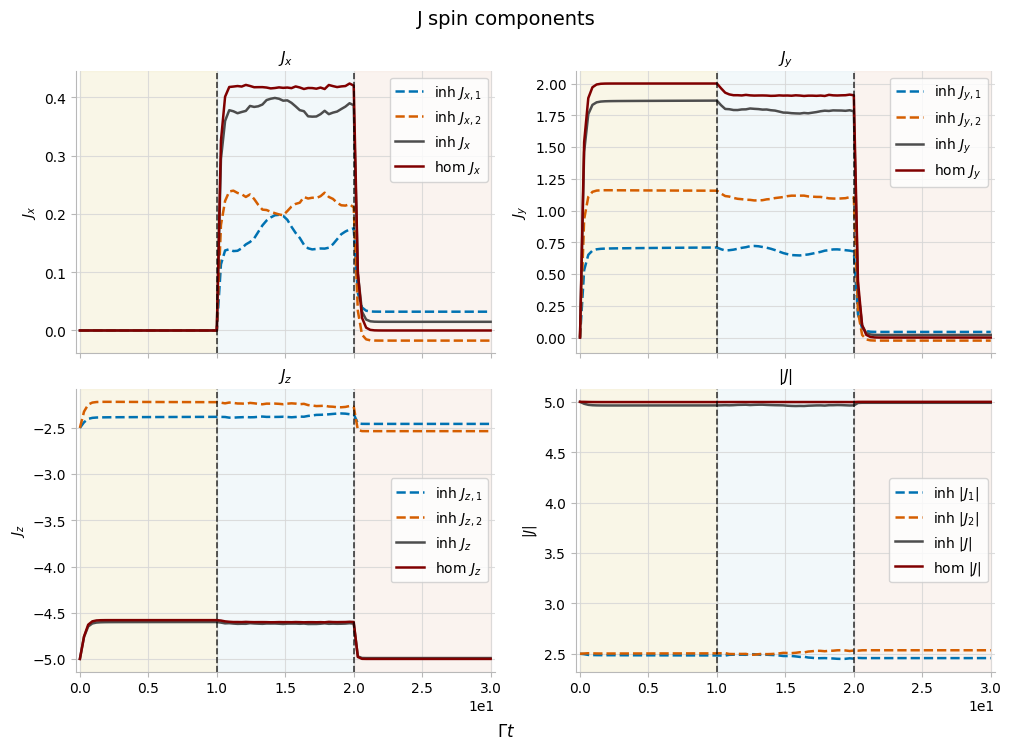

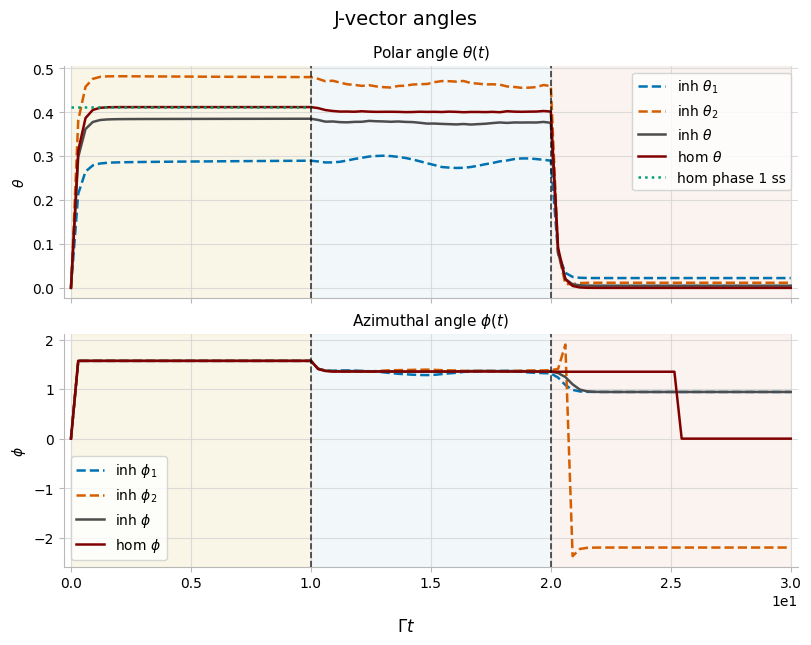

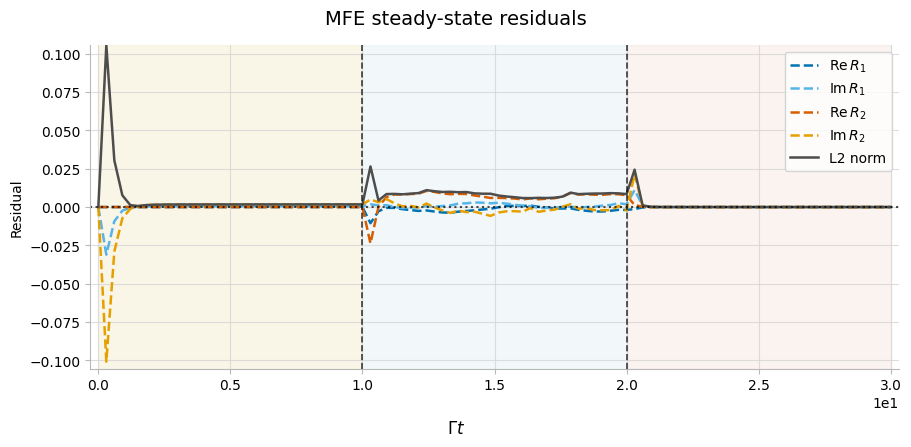

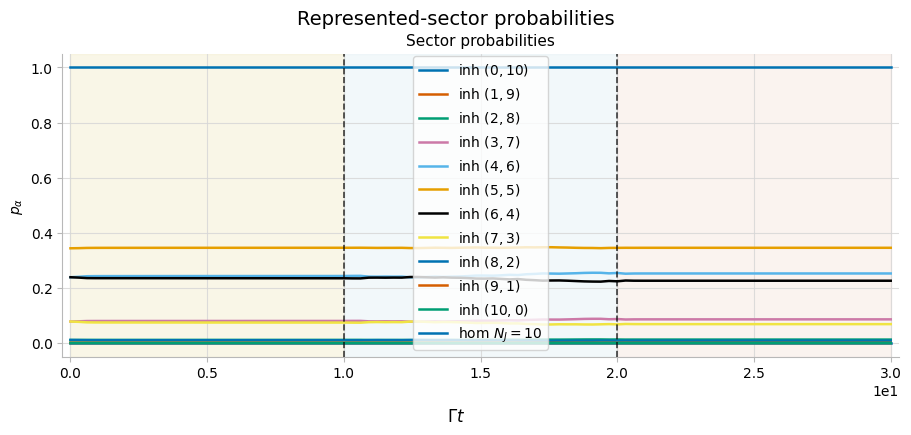

In [26]:
from common.plotting import (
    plot_spin_components,
    plot_j_angles,
    plot_mfe_residuals,
    plot_sector_probabilities,
)

fig, axes = plot_spin_components(
    inh_moments.J,
    phases=phases,
    label="inh",
    # output_path = output_dir / "J_spin_components.png",
    )
fig, axes = plot_spin_components(
    h_moments.J,
    phases=phases,
    label="hom",
    axes=axes,
    colour_index=1,
    output_path = output_dir / "J_spin_components.png",
    )

fig, axes = plot_j_angles(
    inh_moments.J,
    phases=phases,
    label = "inh",
    # output_path = output_dir / "J_spin_angles.png",
)
fig, axes = plot_j_angles(
    h_moments.J,
    phases=phases,
    label="hom",
    show_phase1_ss=True,
    Gamma = h_moments.parameters.Gamma,
    axes=axes,
    colour_index=1,
    output_path = output_dir / "J_spin_angles.png",
)

fig, axes = plot_mfe_residuals(
    inh_moments.J,
    phases=phases,
    output_path = output_dir / "MFE_residuals.png",
)


fig, axes = plot_sector_probabilities(
    inhomogeneous_ensemble,
    phases=phases,
    label="inh",
)
fig, axes = plot_sector_probabilities(
    homogeneous_ensemble,
    phases=phases,
    label="hom",
    axes=axes,
    output_path = output_dir / "sector_probabilities.png",
)


In [18]:
h_moments.J.z

array([-5.        , -4.99756503, -4.9963763 , -4.99608305, -4.99601697,
       -4.99600235, -4.99599913, -4.99599842, -4.99599826, -4.99599823,
       -4.99599822, -4.99599822, -4.99599822, -4.99599822, -4.99599822,
       -4.99599822, -4.99599822, -4.99599822, -4.99599822, -4.99599822,
       -4.99599822, -4.99599822, -4.99599822, -4.99599822, -4.99599822,
       -4.99599822, -4.99599822, -4.99599822, -4.99599822, -4.99599822,
       -4.99599822, -4.99599822, -4.99599822, -4.99599822, -4.99604384,
       -4.99610976, -4.99613972, -4.99614933, -4.99615193, -4.99615255,
       -4.9961483 , -4.99615191, -4.99615259, -4.9961527 , -4.99615272,
       -4.99615272, -4.99615095, -4.99615242, -4.99615268, -4.99614872,
       -4.996152  , -4.99615261, -4.99615271, -4.99615272, -4.99615272,
       -4.99615272, -4.99615272, -4.99615272, -4.99615272, -4.99615272,
       -4.99615272, -4.99615272, -4.99615272, -4.99615272, -4.99614725,
       -4.99615171, -4.99615255, -4.99981407, -4.99999102, -4.99